In [1]:
%matplotlib inline
import pandas as pd
import sys
import shutil
from alpenglow.experiments import BatchFactorExperiment, ExternalModelExperiment
from alpenglow.evaluation import DcgScore
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('http://info.ilab.sztaki.hu/~fbobee/alpenglow/tutorial_dataset.csv', header=None, names=['time', 'user', 'item'])

# recbole model

In [3]:
exp = ExternalModelExperiment(
    period_length=60 * 60 * 24 * 7 * 4,
    in_name_base="batches/batch",
    mode="read",
)

In [4]:
res = exp.run(data, exclude_known=True)

running experiment...


0%-1%-2%-3%-4%-5%-6%-7%-8%-9%-10%-11%-12%-13%-14%-15%-16%-17%-18%-19%-20%-21%-22%-23%-24%-25%-26%-27%-28%-29%-30%-31%-32%-33%-34%-35%-36%-37%-38%-39%-40%-41%-42%-43%-44%-45%-46%-47%-48%-49%-50%-51%-52%-53%-54%-55%-56%-57%-58%-59%-60%-61%-62%-63%-64%-65%-66%-67%-68%-69%-70%-71%-72%-73%-74%-75%-76%-77%-78%-79%-80%-81%-82%-83%-84%-85%-86%-87%-88%-89%-90%-91%-92%-93%-94%-95%-96%-97%-98%-99%-OK


In [5]:
res['dcg'] = DcgScore(res)

In [6]:
res['dcg'].mean()

0.016901799998269153

# alpenglow batch factor model

In [7]:
exp = BatchFactorExperiment(
    period_length=60 * 60 * 24 * 7 * 4,
    negative_rate=5
)
res2 = exp.run(data, exclude_known=True)

running experiment...


0%-1%-2%-3%-4%-5%-6%-7%-8%-9%-10%-11%-12%-13%-14%-15%-16%-17%-18%-19%-20%-21%-22%-23%-24%-25%-26%-27%-28%-29%-30%-31%-32%-33%-34%-35%-36%-37%-38%-39%-40%-41%-42%-43%-44%-45%-46%-47%-48%-49%-50%-51%-52%-53%-54%-55%-56%-57%-58%-59%-60%-61%-62%-63%-64%-65%-66%-67%-68%-69%-70%-71%-72%-73%-74%-75%-76%-77%-78%-79%-80%-81%-82%-83%-84%-85%-86%-87%-88%-89%-90%-91%-92%-93%-94%-95%-96%-97%-98%-99%-OK


In [8]:
res2['dcg'] = DcgScore(res2)

In [9]:
res2['dcg'].mean()

0.01798873345672165

# plotting

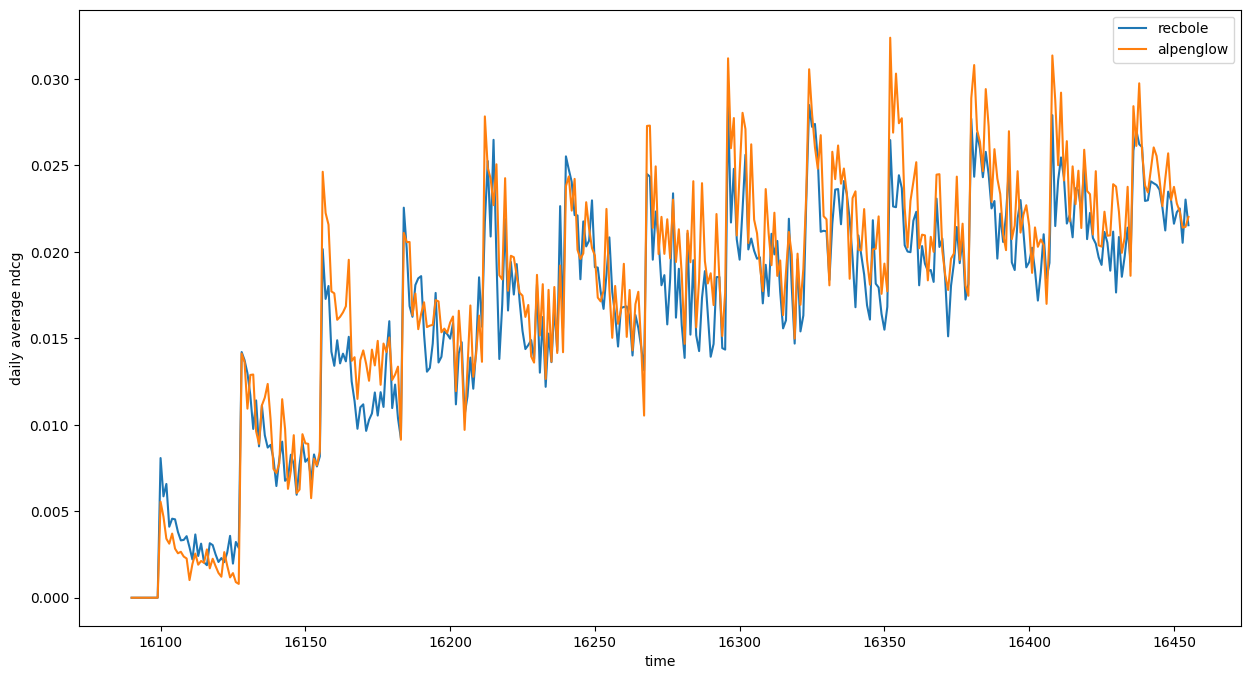

In [10]:
plt.figure(figsize=(15,8))
res.groupby(res.time//(60*60*24)).dcg.mean().plot()
res2.groupby(res2.time//(60*60*24)).dcg.mean().plot()
plt.ylabel('daily average ndcg')
plt.legend(['recbole', 'alpenglow'])